In [81]:
import ray
import healpy as hp
import numpy as np

from adam_core.coordinates import SphericalCoordinates, transform_coordinates, Origin
from adam_core.utils.iter import _iterate_chunk_indices

from thor.observations.observations import Observations  # THOR type


import quivr as qv

In [82]:
observations_filepath = "/Users/b612foundation/b612_packages/adam-thor-research/research/observations_30day_3.parquet"

In [117]:
observations_no_frame = Observations.from_parquet(observations_filepath)

#print the analysis observations frame
print(observations_no_frame.coordinates.frame)
print(observations_no_frame.coordinates.time.scale)



unspecified
tai


In [112]:
observations_no_frame = qv.defragment(observations_no_frame)

coords_src = qv.defragment(observations_no_frame.coordinates)

coords_eq = SphericalCoordinates.from_kwargs(
    rho=coords_src.rho,
    lon=coords_src.lon,
    lat=coords_src.lat,
    vrho=coords_src.vrho,
    vlon=coords_src.vlon,
    vlat=coords_src.vlat,
    time=coords_src.time,
    covariance=coords_src.covariance,
    origin=coords_src.origin,
    frame="equatorial",
)

observations = Observations.from_kwargs(
    id=observations_no_frame.id,
    exposure_id=observations_no_frame.exposure_id,
    night=observations_no_frame.night,
    coordinates=coords_eq,
    photometry=observations_no_frame.photometry,
    state_id=observations_no_frame.state_id,
)

In [113]:
print(observations.coordinates.lat)
print(observations.coordinates.lon)
print(observations.coordinates.time)
print(observations.coordinates.origin)
print(observations.coordinates.frame)



[
  -39.169698550050185,
  -37.05758943403691,
  -37.67773166956555,
  -39.2762397303701,
  -38.779885314759554,
  -39.25530491514932,
  -38.771445623764926,
  -39.109837691980125,
  -38.37995010849997,
  -36.58781605885763,
  ...
  -31.887901771860633,
  -31.571645048015522,
  -32.05123824041276,
  -31.3099904074318,
  -31.813643321164037,
  -33.76017322244876,
  -33.35735287548697,
  -31.17603663908962,
  -31.9924395760173,
  -31.96128863499384
]
[
  84.45228185695676,
  83.77910381256508,
  85.57521001643804,
  83.07640079875344,
  83.160855711503,
  83.10301063036957,
  82.37699037780578,
  81.4935104955142,
  83.76472373752206,
  83.14059365990646,
  ...
  192.6743224856402,
  190.22242384060633,
  193.2549173605907,
  189.20574973214937,
  190.99210474072692,
  191.62736551250035,
  190.06864780195053,
  190.5794909581758,
  191.89840604597254,
  188.28832172756103
]
Timestamp(size=41552445)
Origin(size=41552445)
equatorial


0.2098234113027917
20405


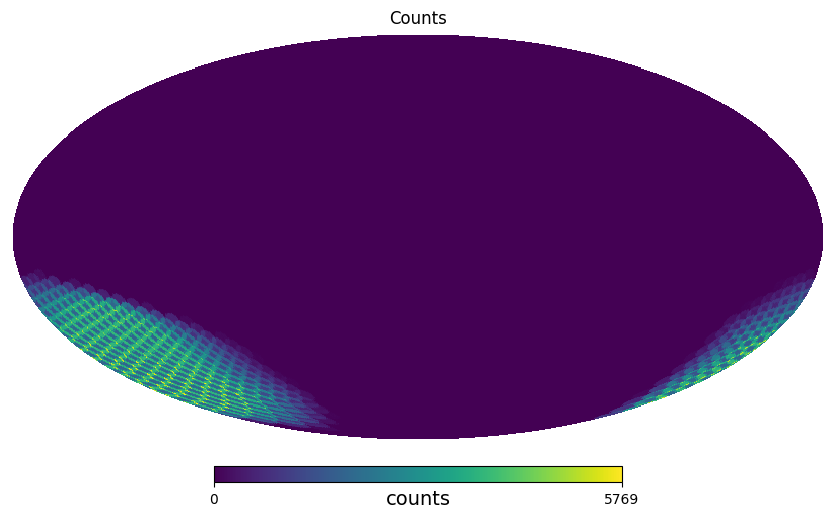

In [86]:
NSIDE = 128
print(hp.nside2pixarea(NSIDE, degrees=True))
analysis_observations = observations

@ray.remote
def worker(indices, analysis_observations):
    # Take a defragmented slice for this worker
    analysis_observations_chunk = qv.defragment(analysis_observations[indices[0] : indices[1]])

    analysis_coordinates_chunk = SphericalCoordinates.from_kwargs(
        rho=np.ones(len(analysis_observations_chunk)),
        lon=analysis_observations_chunk.coordinates.lon,
        lat=analysis_observations_chunk.coordinates.lat,
        frame="equatorial",
        time=analysis_observations_chunk.coordinates.time,
        origin=analysis_observations_chunk.coordinates.origin,
    )
    analysis_coordinates_ecliptic = transform_coordinates(
        analysis_coordinates_chunk, frame_out="ecliptic"
    )

    # Convert to numpy and filter out invalid latitudes
    lon = analysis_coordinates_ecliptic.lon.to_numpy(zero_copy_only=False)
    lat = analysis_coordinates_ecliptic.lat.to_numpy(zero_copy_only=False)

    pixels = hp.ang2pix(NSIDE, lon, lat, lonlat=True, nest=True)

    return pixels


analysis_observations_ref = ray.put(analysis_observations)

futures = []
chunks = []
for chunk_indices in _iterate_chunk_indices(analysis_observations, 100_000):
    futures.append(worker.remote(chunk_indices, analysis_observations_ref))
    if len(futures) >= 90:
        results = ray.get(futures)     # batch get
        chunks.extend(results)         # collect arrays
        futures = []

if futures:
    results = ray.get(futures)
    chunks.extend(results)

pixels = np.concatenate(chunks)        # single concatenate

unique_pixels, counts = np.unique(pixels, return_counts=True)

print(len(unique_pixels))

healpix_map = np.zeros(hp.nside2npix(NSIDE))
for pixel, count in zip(unique_pixels, counts):
    healpix_map[pixel] = count


hp.mollview(healpix_map, title="Counts", unit="counts", nest=True)

In [87]:
#print the 10 healpixels with the highest counts
for i in range(10):
    print(f"The #{i+1} healpixel with the highest counts is {np.argmax(healpix_map)} with {np.max(healpix_map)} counts")
    healpix_map[np.argmax(healpix_map)] = 0

#find ou


The #1 healpixel with the highest counts is 149300 with 5769.0 counts
The #2 healpixel with the highest counts is 153671 with 5762.0 counts
The #3 healpixel with the highest counts is 152420 with 5756.0 counts
The #4 healpixel with the highest counts is 151809 with 5745.0 counts
The #5 healpixel with the highest counts is 150751 with 5738.0 counts
The #6 healpixel with the highest counts is 152866 with 5737.0 counts
The #7 healpixel with the highest counts is 151674 with 5717.0 counts
The #8 healpixel with the highest counts is 148848 with 5716.0 counts
The #9 healpixel with the highest counts is 151784 with 5710.0 counts
The #10 healpixel with the highest counts is 174593 with 5703.0 counts


In [ ]:
from thor.phase_space.healpixel import create_healpixel_test_orbits
from adam_core.time import Timestamp
from adam_core.coordinates import OriginCodes

# Simple binning in rho (au), eccentricity, true anomaly, and psi
rho_bin_edges = np.array([1.0, 1.2, 1.4, 1.6, 1.8])
e_bin_edges   = np.linspace(0.0, 0.8, 5)
nu_bin_edges  = np.linspace(-180.0, 180.0, 5)
psi_bin_edges = np.linspace(-90.0, 90.0, 5)

# Use a representative time from your THOR observations
time_observations = observations.coordinates.time[:1]                  # first timestamp

# Use the healpixels you found earlier (e.g. from your sky map)
pixels = [153125]                                    # or e.g. unique_pixels[:100]

test_orbits = create_healpixel_test_orbits(
    rho_bin_edges=rho_bin_edges,
    e_bin_edges=e_bin_edges,
    nu_bin_edges=nu_bin_edges,
    psi_bin_edges=psi_bin_edges,
    time=time_observations,
    origin=OriginCodes.SOLAR_SYSTEM_BARYCENTER,
    nside=NSIDE,                                          # same NSIDE as your map
    pixels=pixels,
    chunk_size=100,
    max_processes=10,
)



tai


In [119]:
print(test_orbits.coordinates.time.scale)
print(observations.coordinates.time.scale)

tai
tai


In [89]:
print(test_orbits)

#visualize the test orbits

TestOrbits(size=256)


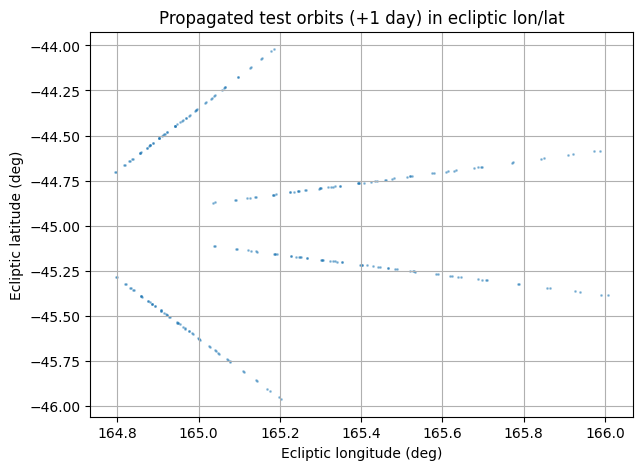

In [114]:
import numpy as np
import matplotlib.pyplot as plt

from adam_assist import ASSISTPropagator
from adam_core.time import Timestamp
from adam_core.coordinates import SphericalCoordinates, transform_coordinates

# 1) Propagate all test orbits by +1 day from their initial epoch
t0 = test_orbits.coordinates.time.min()          # single Timestamp row
t1 = t0.add_days(1)

prop_orbits = test_orbits.propagate(
    times=t1,
    propagator_class=ASSISTPropagator,
    max_processes=4,
)

# 2) Convert propagated Cartesian coordinates → spherical ecliptic lon/lat
coords_sph = transform_coordinates(
    prop_orbits.coordinates,
    representation_out=SphericalCoordinates,
    frame_out="ecliptic",
)

lon = coords_sph.lon.to_numpy(zero_copy_only=False)
lat = coords_sph.lat.to_numpy(zero_copy_only=False)

# 3) Simple lon/lat scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(lon, lat, s=1, alpha=0.4)
plt.xlabel("Ecliptic longitude (deg)")
plt.ylabel("Ecliptic latitude (deg)")
plt.title("Propagated test orbits (+1 day) in ecliptic lon/lat")
plt.grid(True)
plt.show()

In [97]:
from datetime import datetime
#save the orbits to a descriptive file
print(f"test_orbits_153125_{datetime.now().isoformat()}.parquet")
#test_orbits.to_parquet(f"test_orbits_153125_{datetime.now().isoformat()}.parquet")

test_orbits_153125_2025-12-03T15:26:49.498021.parquet


In [ ]:
from thor.main import link_test_orbit, Config
import os

config = Config()
working_dir = "/Users/b612foundation/b612_packages/thor_healpix_run"
os.makedirs(working_dir, exist_ok=True)

all_stage_summaries = []

for i in range(len(test_orbits)):
    this_orbit = test_orbits[i : i + 1]   # length-1 TestOrbits
    print(f"\n=== Orbit {i+1}/{len(test_orbits)}: {this_orbit.orbit_id[0].as_py()} ===")

    stages = list(
        link_test_orbit(
            test_orbit=this_orbit,
            observations=observations,
            working_dir=working_dir,
            config=config,
        )
    )

    # Summarize each stage
    for stage in stages:
        print(stage.name, [len(tbl) for tbl in stage.result], stage.path)
    all_stage_summaries.append((this_orbit.orbit_id[0].as_py(), stages))


=== Orbit 1/256: 153125_r1.100_e0.100_nu-135.000_psi-67.500 ===
16:22:56.866 [INFO] thor - Running test orbit...
16:22:56.867 [INFO] thor - Using working directory: /Users/b612foundation/b612_packages/thor_healpix_run
16:22:56.870 [INFO] thor - Saving configuration to /Users/b612foundation/b612_packages/thor_healpix_run/inputs/config.json...
16:22:56.871 [INFO] thor - Found recovered orbits, pipeline is complete.
16:22:56.877 [INFO] thor - Starting at stage: complete
16:22:56.878 [INFO] thor - Found recovered orbits in checkpoint, exiting early...

=== Orbit 2/256: 153125_r1.100_e0.100_nu-135.000_psi-22.500 ===
16:22:56.878 [INFO] thor - Running test orbit...
16:22:56.878 [INFO] thor - Using working directory: /Users/b612foundation/b612_packages/thor_healpix_run
16:22:56.880 [INFO] thor - Saving configuration to /Users/b612foundation/b612_packages/thor_healpix_run/inputs/config.json...
16:22:56.882 [INFO] thor - No filtered observations found, starting stage filter_observations
16:22:

(filter_observations_worker pid=23679) /Users/b612foundation/b612_packages/adam-thor-research/.venv/lib/python3.12/site-packages/adam_core/coordinates/residuals.py:397: UserWarning: Covariance matrix has NaNs on the off-diagonal (these will be assumed to be 0.0).
(filter_observations_worker pid=23679)   warnings.warn(


(filter_observations_worker pid=23679) 16:22:58.004 [INFO] thor.observations.filters - Filtered 100000 observations to 0 observations.
(filter_observations_worker pid=23679) 16:22:58.004 [INFO] thor.observations.filters - TestOrbitMahalanobisSphericalObservationFilter completed in 1.098 seconds.
(filter_observations_worker pid=23681) 16:23:01.917 [INFO] thor.observations.filters - Applying TestOrbitMahalanobisObservationFilter... [repeated 49x across cluster]
(filter_observations_worker pid=23681) 16:23:01.918 [INFO] thor.observations.filters - Using mahalanobis_distance = 5.0-sigma [repeated 49x across cluster]


(filter_observations_worker pid=23678) /Users/b612foundation/b612_packages/adam-thor-research/.venv/lib/python3.12/site-packages/adam_core/coordinates/residuals.py:397: UserWarning: Covariance matrix has NaNs on the off-diagonal (these will be assumed to be 0.0). [repeated 47x across cluster]
(filter_observations_worker pid=23678)   warnings.warn( [repeated 47x across cluster]


(filter_observations_worker pid=23683) 16:23:02.937 [INFO] thor.observations.filters - Filtered 100000 observations to 0 observations. [repeated 49x across cluster]
(filter_observations_worker pid=23683) 16:23:02.937 [INFO] thor.observations.filters - TestOrbitMahalanobisSphericalObservationFilter completed in 1.068 seconds. [repeated 49x across cluster]
(filter_observations_worker pid=23676) 16:23:06.745 [INFO] thor.observations.filters - Applying TestOrbitMahalanobisObservationFilter... [repeated 43x across cluster]
(filter_observations_worker pid=23676) 16:23:06.745 [INFO] thor.observations.filters - Using mahalanobis_distance = 5.0-sigma [repeated 43x across cluster]


...

(filter_observations_worker pid=23680) 16:24:39.723 [INFO] thor.observations.filters - Filtered 100000 observations to 0 observations. [repeated 30x across cluster]
(filter_observations_worker pid=23680) 16:24:39.723 [INFO] thor.observations.filters - TestOrbitMahalanobisSphericalObservationFilter completed in 1.775 seconds. [repeated 30x across cluster]
(filter_observations_worker pid=23676) 16:24:44.448 [INFO] thor.observations.filters - Applying TestOrbitMahalanobisObservationFilter... [repeated 33x across cluster]
(filter_observations_worker pid=23676) 16:24:44.448 [INFO] thor.observations.filters - Using mahalanobis_distance = 5.0-sigma [repeated 33x across cluster]


(filter_observations_worker pid=23682) /Users/b612foundation/b612_packages/adam-thor-research/.venv/lib/python3.12/site-packages/adam_core/coordinates/residuals.py:397: UserWarning: Covariance matrix has NaNs on the off-diagonal (these will be assumed to be 0.0). [repeated 36x across cluster]
(filter_observations_worker pid=23682)   warnings.warn( [repeated 36x across cluster]


(filter_observations_worker pid=23679) 16:24:45.066 [INFO] thor.observations.filters - Filtered 100000 observations to 0 observations. [repeated 33x across cluster]
(filter_observations_worker pid=23679) 16:24:45.066 [INFO] thor.observations.filters - TestOrbitMahalanobisSphericalObservationFilter completed in 1.313 seconds. [repeated 33x across cluster]
16:24:45.555 [INFO] thor.observations.filters - Filtered 41552445 observations to 11668 observations.
16:24:45.556 [INFO] thor.observations.filters - Observations filters completed in 59.855 seconds.
16:24:45.576 [INFO] thor - Placed filtered observations in the object store.
16:24:45.576 [INFO] thor.range_and_transform - Running range and transform...
16:24:45.578 [INFO] thor.range_and_transform - Assuming r = [-0.75006039  0.20624899 -0.77773438] au
16:24:45.578 [INFO] thor.range_and_transform - Assuming v = [-0.00718128 -0.013183    0.00513222] au/d
16:24:45.581 [INFO] thor.range_and_transform - Retrieved observations from the objec

RayTaskError(AssertionError): [36mray::range_and_transform_worker()[39m (pid=23679, ip=127.0.0.1)
  File "/Users/b612foundation/b612_packages/adam-thor-research/.venv/lib/python3.12/site-packages/thor/range_and_transform.py", line 96, in range_and_transform_worker
  File "/Users/b612foundation/b612_packages/adam-thor-research/.venv/lib/python3.12/site-packages/thor/projections/gnomonic.py", line 131, in from_cartesian
    assert cartesian.time.scale == center_cartesian.time.scale
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError

2025-12-03 16:24:54,181	ERROR worker.py:430 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): ray::range_and_transform_worker() (pid=23681, ip=127.0.0.1)
  File "/Users/b612foundation/b612_packages/adam-thor-research/.venv/lib/python3.12/site-packages/thor/range_and_transform.py", line 96, in range_and_transform_worker
  File "/Users/b612foundation/b612_packages/adam-thor-research/.venv/lib/python3.12/site-packages/thor/projections/gnomonic.py", line 131, in from_cartesian
    assert cartesian.time.scale == center_cartesian.time.scale
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError
2025-12-03 16:24:54,182	ERROR worker.py:430 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): ray::range_and_transform_worker() (pid=23683, ip=127.0.0.1)
  File "/Users/b612foundation/b612_packages/adam-thor-research/.venv/lib/python3.12/site-packages/thor/range_and_transform.py", line 96, in range_and_transform_worker
  File "/Users/b612found